# Universe discovery — US tech monthly rotating backtest

Exploratory discovery run (not sealed STAR OOS). Same **method.md** gated pipeline as the airline notebook: nested industry leaves → shortability → ADV → corr → EG + BH-FDR → cost vs |z|=2 → persistence → HL → capped book. Retests **monthly**; empty months go flat.

| Knob | Value | Why |
|------|--------|-----|
| β / OLS | 252 | Stack default |
| Discovery L | 252 | Trailing year at each month-end |
| z window | `clip(2 × HL_{t-1}, 20, 120)` | `adaptive_zscore` |
| Entry / exit | `|z| > 2` / mean | `entry_z=2`, `exit_z=0` |
| Universe | ≤1000 US-listed tech (Technology + Telecommunications + tech industries) | `tech_pools.load_us_tech_pools` (Nasdaq screener cache; typically ~750–850 names) |
| Leaves | Industry shards (max 25 names) | Keeps within-leaf pair counts tractable |

Fetch + Alpaca shortability prune the live set. **Restart kernel and run all** after edits.


## 0. Imports & Config


In [23]:
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

cur = os.path.abspath(os.getcwd())
ROOT = cur
for _ in range(12):
    if os.path.isfile(os.path.join(cur, "pyproject.toml")) and os.path.isdir(
        os.path.join(cur, "02_research")
    ):
        ROOT = cur
        break
    parent = os.path.dirname(cur)
    if parent == cur:
        break
    cur = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

DISC = os.path.join(ROOT, "02_research", "s2_coint", "notebooks", "universe_discovery")
if DISC not in sys.path:
    sys.path.insert(0, DISC)

from backtest.s2_coint.diagnosis import gross_returns_from_net
from backtest.s2_coint.rotation import SLOT_WEIGHT, book_composition
from backtest.s2_coint.tearsheet import (
    cvar,
    equity_from_returns,
    monthly_returns,
    oos_headline_metrics,
    plot_drawdown,
    plot_equity_net_gross,
    plot_monthly_heatmap,
)
from data.ingestion.equity_fetcher import fetch_ohlcv
from data.processing.s2_coint_store import build_pair_panel, compute_adaptive_zscore
from data.processing.s2_universe import pool_tickers
from strategies.s2_coint.config import S2SimConfig
from strategies.s2_coint.metrics import (
    book_returns_to_calendar,
    metrics_from_returns,
    panel_session_dates,
)

from screen import (
    CORR_MIN,
    COST_PROFILE_DEFAULT,
    COST_TO_MOVE_MAX,
    EMPTY_BOOK_PAIR_ID,
    FDR_Q,
    HL_MAX,
    LOOKBACK_BARS,
    MIN_ADV_USD,
    OLS_WINDOW,
    PERSISTENCE_FLOOR,
    Z_ENTRY,
    active_pair_ids,
    build_monthly_schedule,
    funnel_counts,
    month_end_rebalance_dates,
    screen_universe,
    simulate_monthly_rotating_book,
)
from tech_pools import (
    MAX_LEAF,
    TARGET_N,
    filter_pools_to_tickers,
    load_us_tech_pools,
    tech_ticker_count,
)

# Refresh=False uses cached screener CSV under universe_discovery/cache/
POOLS = load_us_tech_pools(target_n=TARGET_N, max_leaf=MAX_LEAF, refresh=False)

START = "2015-01-01"
END = None
BAR = "1d"
CAP_GLOBAL = 6
CAP_PER_POOL = 2
SKIP_SHORTABILITY = False
N_TRIALS_LOCAL = 1

print("ROOT", ROOT)
print("tech candidates", tech_ticker_count(POOLS), "leaves", len(POOLS), "max_leaf", MAX_LEAF)
print(
    "gates",
    dict(
        OLS_WINDOW=OLS_WINDOW,
        LOOKBACK_BARS=LOOKBACK_BARS,
        CORR_MIN=CORR_MIN,
        FDR_Q=FDR_Q,
        HL_MAX=HL_MAX,
        PERSISTENCE_FLOOR=PERSISTENCE_FLOOR,
        MIN_ADV_USD=MIN_ADV_USD,
        COST_TO_MOVE_MAX=COST_TO_MOVE_MAX,
        Z_ENTRY=Z_ENTRY,
    ),
)


ROOT c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
tech candidates 784 leaves 38 max_leaf 25
gates {'OLS_WINDOW': 252, 'LOOKBACK_BARS': 252, 'CORR_MIN': 0.9, 'FDR_Q': 0.1, 'HL_MAX': 40.0, 'PERSISTENCE_FLOOR': 0.4, 'MIN_ADV_USD': 5000000.0, 'COST_TO_MOVE_MAX': 0.25, 'Z_ENTRY': 2.0}


## 1. Data


In [24]:
tickers = pool_tickers(POOLS)
ohlc_by_ticker: dict[str, pd.DataFrame] = {}
fetch_fail: list[str] = []
for i, t in enumerate(tickers, start=1):
    try:
        raw = fetch_ohlcv(t, START, END, interval=BAR, auto_adjust=False)
    except Exception as exc:
        fetch_fail.append(t)
        if i % 50 == 0 or i == len(tickers):
            print(f"fetch progress {i}/{len(tickers)} fail={len(fetch_fail)}")
        continue
    if raw is None or raw.empty:
        fetch_fail.append(t)
    else:
        g = raw.copy()
        g["date"] = pd.to_datetime(g["date"])
        g = g.set_index("date").sort_index()
        ohlc_by_ticker[t] = g[["open", "high", "low", "close", "volume"]].astype(float)
    if i % 50 == 0 or i == len(tickers):
        print(f"fetch progress {i}/{len(tickers)} ok={len(ohlc_by_ticker)} fail={len(fetch_fail)}")

POOLS = filter_pools_to_tickers(POOLS, list(ohlc_by_ticker))
tickers = pool_tickers(POOLS)
ohlc_by_ticker = {t: ohlc_by_ticker[t] for t in tickers}
closes = {t: df["close"] for t, df in ohlc_by_ticker.items()}
sessions = (
    pd.DatetimeIndex(sorted(set().union(*[set(s.index) for s in closes.values()])))
    if closes
    else pd.DatetimeIndex([])
)
print("priced tickers", len(tickers), "leaves", len(POOLS))
print("fetch_fail sample", fetch_fail[:30], ("..." if len(fetch_fail) > 30 else ""))
print(
    "sessions",
    len(sessions),
    sessions.min() if len(sessions) else None,
    "→",
    sessions.max() if len(sessions) else None,
)


fetch progress 50/784 ok=50 fail=0
fetch progress 100/784 ok=100 fail=0
fetch progress 150/784 ok=150 fail=0
fetch progress 200/784 ok=200 fail=0
fetch progress 250/784 ok=250 fail=0
fetch progress 300/784 ok=300 fail=0
fetch progress 350/784 ok=350 fail=0
fetch progress 400/784 ok=400 fail=0
fetch progress 450/784 ok=450 fail=0
fetch progress 500/784 ok=500 fail=0
fetch progress 550/784 ok=550 fail=0
fetch progress 600/784 ok=600 fail=0
fetch progress 650/784 ok=650 fail=0
fetch progress 700/784 ok=700 fail=0
fetch progress 750/784 ok=750 fail=0
fetch progress 784/784 ok=784 fail=0
priced tickers 784 leaves 38
fetch_fail sample [] 
sessions 2936 2015-01-02 00:00:00 → 2026-09-04 00:00:00


In [25]:
shortable_by_ticker: dict[str, bool] | None = None
if SKIP_SHORTABILITY:
    print("SKIP_SHORTABILITY=True — shortability gate disabled")
else:
    try:
        from execution.brokers.alpaca_broker import (
            AlpacaBroker,
            S2_ALPACA_API_KEY,
            S2_ALPACA_SECRET_KEY,
        )

        broker = AlpacaBroker(
            paper=True,
            api_key_name=S2_ALPACA_API_KEY,
            secret_key_name=S2_ALPACA_SECRET_KEY,
        )
        rows = broker.get_asset_shortability(tickers)
        short_df = pd.DataFrame(rows)
        display(short_df.head(20))
        shortable_by_ticker = {
            str(r["ticker"]): bool(r.get("shortable")) and bool(r.get("found"))
            for r in rows
        }
        keep = {t for t, ok in shortable_by_ticker.items() if ok}
        dropped = [t for t in tickers if t not in keep]
        print("drop not shortable / not found:", len(dropped), dropped[:40], ("..." if len(dropped) > 40 else ""))
        POOLS = filter_pools_to_tickers(POOLS, keep)
        tickers = pool_tickers(POOLS)
        ohlc_by_ticker = {t: ohlc_by_ticker[t] for t in tickers if t in ohlc_by_ticker}
        closes = {t: ohlc_by_ticker[t]["close"] for t in tickers}
        sessions = (
            pd.DatetimeIndex(sorted(set().union(*[set(s.index) for s in closes.values()])))
            if closes
            else pd.DatetimeIndex([])
        )
        shortable_by_ticker = {t: True for t in tickers}
        print("Alpaca-shortable tickers", len(tickers), "leaves", len(POOLS))
    except Exception as exc:
        print("Alpaca shortability unavailable:", type(exc).__name__, exc)
        print("Falling back to SKIP_SHORTABILITY=True for this run")
        SKIP_SHORTABILITY = True
        shortable_by_ticker = None


,ticker,alpaca_symbol,shortable,easy_to_borrow,found,error
0,NVDA,NVDA,True,True,True,
1,TSM,TSM,True,True,True,
2,AVGO,AVGO,True,True,True,
3,MU,MU,True,True,True,
4,AMD,AMD,True,True,True,
5,INTC,INTC,True,True,True,
6,AMAT,AMAT,True,True,True,
7,TXN,TXN,True,True,True,
8,MRVL,MRVL,True,True,True,
9,ADI,ADI,True,True,True,


drop not shortable / not found: 253 ['LAES', 'VLN', 'GCTS', 'SPWR', 'BZAI', 'SPCB', 'NAN', 'SNSC', 'ASTI', 'MOBX', 'LEDS', 'PRSO', 'SSM', 'SMTK', 'XNDU', 'SCKT', 'BSP', 'RUM', 'RZLV', 'SMWB', 'SANG', 'GOAI', 'PODC', 'TEAD', 'HOLO', 'SST', 'GMM', 'MF', 'IPM', 'GIGM', 'RCT', 'KNRX', 'GITS', 'RMSG', 'TWAV', 'CNET', 'LCFY', 'CSAI', 'YYAI', 'IPDN'] ...
Alpaca-shortable tickers 529 leaves 34


## 2. One-shot screen sanity

Run the full method.md funnel at a fixed `asof` (mid-sample) to inspect survivors and reject reasons.


In [26]:
if len(sessions) < LOOKBACK_BARS + 60:
    asof_sanity = sessions[-1] if len(sessions) else pd.Timestamp(START)
else:
    asof_sanity = sessions[LOOKBACK_BARS + (len(sessions) - LOOKBACK_BARS) // 2]

screen_once = screen_universe(
    ohlc_by_ticker,
    POOLS,
    asof=asof_sanity,
    lookback_bars=LOOKBACK_BARS,
    ols_window=OLS_WINDOW,
    per_pool_cap=CAP_PER_POOL,
    global_cap=CAP_GLOBAL,
    shortable_by_ticker=shortable_by_ticker,
    skip_shortability=SKIP_SHORTABILITY,
    cost_profile=COST_PROFILE_DEFAULT,
)
print("asof", asof_sanity)
print("funnel")
display(funnel_counts(screen_once).to_frame())
cols = [
    "pair_id",
    "pool",
    "corr",
    "pvalue",
    "fdr_pass",
    "discovery_half_life",
    "pct_adf_lt_005",
    "rt_cost_bps",
    "z2_move_bps",
    "cost_to_move",
    "exclude_reason",
    "passed",
    "auto_selected",
]
display(
    screen_once.sort_values(["passed", "pvalue"], ascending=[False, True])[cols].head(40)
)


asof 2021-05-04 00:00:00
funnel


,n
exclude_reason,
liquidity,2876
corr,2006
not_passer,2


,pair_id,pool,corr,pvalue,fdr_pass,discovery_half_life,pct_adf_lt_005,rt_cost_bps,z2_move_bps,cost_to_move,exclude_reason,passed,auto_selected
858,GOOGL|GOOG,computer_software_programming_data_processing_0,0.995169,0.050354,False,NaN,NaN,NaN,NaN,NaN,not_passer,False,False
4832,LBTYA|LBTYK,cable_other_pay_television_services,0.977042,0.106006,False,NaN,NaN,NaN,NaN,NaN,not_passer,False,False
0,NVDA|TSM,semiconductors_0,0.503880,NaN,False,NaN,NaN,NaN,NaN,NaN,corr,False,False
1,AVGO|NVDA,semiconductors_0,0.656837,NaN,False,NaN,NaN,NaN,NaN,NaN,corr,False,False
2,MU|NVDA,semiconductors_0,0.434275,NaN,False,NaN,NaN,NaN,NaN,NaN,corr,False,False
3,AMD|NVDA,semiconductors_0,0.688775,NaN,False,NaN,NaN,NaN,NaN,NaN,corr,False,False
4,INTC|NVDA,semiconductors_0,0.370432,NaN,False,NaN,NaN,NaN,NaN,NaN,corr,False,False
5,AMAT|NVDA,semiconductors_0,0.552606,NaN,False,NaN,NaN,NaN,NaN,NaN,corr,False,False
6,NVDA|TXN,semiconductors_0,0.633208,NaN,False,NaN,NaN,NaN,NaN,NaN,corr,False,False
7,MRVL|NVDA,semiconductors_0,0.636001,NaN,False,NaN,NaN,NaN,NaN,NaN,corr,False,False


## 3. Monthly schedule

Full gated screen at **every** month-end; active set effective next session. Empty months → flat book markers.


In [27]:
rebals = month_end_rebalance_dates(sessions)
if len(sessions) > LOOKBACK_BARS:
    first_ok = sessions[LOOKBACK_BARS - 1]
    rebals = [d for d in rebals if d >= first_ok]

print("month-end dates to screen", len(rebals), "(this can take a while on a large tech book)")
schedule = build_monthly_schedule(
    ohlc_by_ticker,
    POOLS,
    sessions,
    lookback_bars=LOOKBACK_BARS,
    ols_window=OLS_WINDOW,
    per_pool_cap=CAP_PER_POOL,
    global_cap=CAP_GLOBAL,
    rebalance_dates=rebals,
    shortable_by_ticker=shortable_by_ticker,
    skip_shortability=SKIP_SHORTABILITY,
    cost_profile=COST_PROFILE_DEFAULT,
)
n_reb = int(schedule["rebalance_date"].nunique()) if not schedule.empty else 0
n_empty = (
    int((schedule["pair_id"].astype(str).str.strip() == EMPTY_BOOK_PAIR_ID).sum())
    if not schedule.empty
    else 0
)
n_live = len(active_pair_ids(schedule))
print("month-end retests", n_reb, "| empty-book marker rows", n_empty, "| unique live pairs", n_live)
display(schedule.head(20))
live_sched = schedule.loc[schedule["pair_id"].astype(str).str.strip() != EMPTY_BOOK_PAIR_ID]
if not live_sched.empty:
    display(book_composition(live_sched).head(30))
else:
    print("No months selected any pairs — book stays flat (still a valid run).")


month-end dates to screen 130 (this can take a while on a large tech book)
month-end retests 129 | empty-book marker rows 100 | unique live pairs 7


,rebalance_date,effective_date,pair_id,pool,pvalue,rank
0,2015-12-31,2016-01-04,,,NaN,0
1,2016-01-29,2016-02-01,,,NaN,0
2,2016-02-29,2016-03-01,,,NaN,0
3,2016-03-31,2016-04-01,,,NaN,0
4,2016-04-29,2016-05-02,,,NaN,0
5,2016-05-31,2016-06-01,,,NaN,0
6,2016-06-30,2016-07-01,,,NaN,0
7,2016-07-29,2016-08-01,LBTYK|LBTYA,cable_other_pay_television_services,0.016733,1
8,2016-08-31,2016-09-01,LBTYK|LBTYA,cable_other_pay_television_services,0.002197,1
9,2016-09-30,2016-10-03,LBTYK|LBTYA,cable_other_pay_television_services,0.040256,1


,effective_date,pool,n_pairs
0,2016-08-01,cable_other_pay_television_services,1
1,2016-09-01,cable_other_pay_television_services,1
2,2016-10-03,cable_other_pay_television_services,1
3,2017-01-03,cable_other_pay_television_services,1
4,2017-02-01,cable_other_pay_television_services,1
5,2017-10-02,computer_software_programming_data_processing_0,1
6,2018-10-01,cable_other_pay_television_services,1
7,2018-11-01,cable_other_pay_television_services,1
8,2018-12-03,cable_other_pay_television_services,1
9,2019-01-02,cable_other_pay_television_services,1


## 4. Panel (OLS 252 + adaptive z = 2×HL)


In [28]:
def _legs_from_pair_id(pid: str) -> tuple[str, str] | None:
    p = str(pid).strip()
    if not p or p == EMPTY_BOOK_PAIR_ID or "|" not in p:
        return None
    parts = p.split("|")
    if len(parts) != 2 or not parts[0] or not parts[1]:
        return None
    return parts[0], parts[1]


live_pairs = active_pair_ids(schedule)
if not live_pairs:
    any_close = next(iter(ohlc_by_ticker.values()))
    panel = pd.DataFrame({"date": pd.to_datetime(any_close.index)})
    panel["pair_id"] = "__FLAT__"
    panel["spread"] = np.nan
    panel["half_life"] = np.nan
    panel["z"] = np.nan
    panel["beta"] = np.nan
    for col in ("open_y", "high_y", "low_y", "close_y", "open_x", "high_x", "low_x", "close_x"):
        panel[col] = np.nan
    print("No live pairs — flat date spine (", len(panel), "sessions)")
else:
    pair_tuples = []
    seen = set()
    for pid in live_pairs:
        legs = _legs_from_pair_id(pid)
        if legs is None or legs in seen:
            continue
        seen.add(legs)
        pair_tuples.append(legs)
    panel = build_pair_panel(
        ohlc_by_ticker,
        pair_tuples,
        ols_window=OLS_WINDOW,
        z_window=60,
        hl_window=OLS_WINDOW,
        hedge="ols",
        include_adf_pvalue=False,
    )
    parts = []
    for pid, g in panel.groupby("pair_id", sort=False):
        g = g.sort_values("date").copy()
        g["z"] = compute_adaptive_zscore(
            g["spread"], g["half_life"], z_min=20, z_max=120
        ).to_numpy(dtype=float)
        parts.append(g)
    panel = pd.concat(parts, ignore_index=True)
    print("panel rows", len(panel), "pairs", panel["pair_id"].nunique())
    display(panel.head(3))


panel rows 20427 pairs 7


,date,pair_id,ticker_y,ticker_x,open_y,high_y,low_y,close_y,open_x,high_x,low_x,close_x,alpha,beta,spread,z,half_life
0,2015-01-02,AD|TDS,AD,TDS,40.160000,40.189999,39.610001,39.799999,25.379999,25.500000,25.110001,25.309999,NaN,NaN,NaN,NaN,NaN
1,2015-01-05,AD|TDS,AD,TDS,39.230000,39.230000,34.779999,35.669998,25.309999,25.330000,23.520000,23.950001,NaN,NaN,NaN,NaN,NaN
2,2015-01-06,AD|TDS,AD,TDS,35.740002,36.619999,34.709999,35.400002,23.959999,24.360001,23.540001,23.690001,NaN,NaN,NaN,NaN,NaN


## 5. Backtest (full S2 engine)

Signal at close `t`, fill open `t+1`. `overlap_mode=never_allow`. Costs: `US_ALPACA`.


In [29]:
cfg = S2SimConfig(
    hedge="ols",
    bar=BAR,
    entry_z=float(Z_ENTRY),
    exit_z=0.0,
    ols_window=OLS_WINDOW,
    z_window=60,
    hl_window=OLS_WINDOW,
    adf_window=OLS_WINDOW,
    z_window_mode="adaptive",
    z_clip_min=20,
    z_clip_max=120,
    entry_mode="trad_z",
    exit_mode="mean_only",
    break_mode="off",
    trend_mode="off",
    overlap_mode="never_allow",
    size_mode="equal",
    vol_mode="fixed_k",
    cost_profile=COST_PROFILE_DEFAULT,
    use_hedge_ratio_sizing=True,
)

sim = simulate_monthly_rotating_book(
    panel,
    schedule,
    cfg,
    slot_weight=SLOT_WEIGHT,
    apply_short_bans=False,
)
master_dates = (
    panel_session_dates(panel)
    if "pair_id" in panel.columns
    else pd.DatetimeIndex(pd.to_datetime(panel["date"])).unique().sort_values()
)
if len(master_dates) == 0 and len(sessions):
    master_dates = sessions
net = book_returns_to_calendar(sim["returns"], master_dates)
trades = sim["trades"] if isinstance(sim["trades"], pd.DataFrame) else pd.DataFrame()
gross = gross_returns_from_net(net, trades)
rebal_log = sim.get("rebalance_log", pd.DataFrame())

print("n_days", len(net), "n_trades", len(trades), "live pairs ever", len(active_pair_ids(schedule)))
display(rebal_log.head(15) if not rebal_log.empty else rebal_log)


n_days 2936 n_trades 17 live pairs ever 7


,rebalance_date,effective_date,n_active,promoted,demoted,flipped
0,2015-12-31,2016-01-04,0,,,
1,2016-01-29,2016-02-01,0,,,
2,2016-02-29,2016-03-01,0,,,
3,2016-03-31,2016-04-01,0,,,
4,2016-04-29,2016-05-02,0,,,
5,2016-05-31,2016-06-01,0,,,
6,2016-06-30,2016-07-01,0,,,
7,2016-07-29,2016-08-01,1,LBTYK|LBTYA,,
8,2016-08-31,2016-09-01,1,,,
9,2016-09-30,2016-10-03,1,,,


## 6. Universe effectiveness report

**Exploratory discovery** — not sealed STAR OOS.


In [30]:
s1_weekly = None
s1_path = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_period_returns.parquet"
)
if os.path.isfile(s1_path):
    s1 = pd.read_parquet(s1_path)
    if isinstance(s1, pd.DataFrame) and not s1.empty:
        if "ret" in s1.columns:
            s1_weekly = pd.to_numeric(s1["ret"], errors="coerce")
            if "date" in s1.columns:
                s1_weekly.index = pd.to_datetime(s1["date"])
        else:
            num = s1.select_dtypes(include=[np.number])
            if not num.empty:
                s1_weekly = num.iloc[:, 0]

headline = oos_headline_metrics(
    net,
    gross,
    trades=trades,
    s1_weekly=s1_weekly,
    n_trials_local=N_TRIALS_LOCAL,
    n_trials_stack=None,
)
headline["cvar_5"] = float(cvar(net, alpha=0.05))
print("=== headline (net primary) ===")
display(headline.to_frame("value"))


=== headline (net primary) ===


,value
ann_sharpe_net,0.342915
ann_sharpe_gross,0.810599
sortino,0.492668
calmar,0.139898
max_drawdown,-0.009346
cagr,0.001307
total_return,0.015339
psr,0.000000
dsr_local,1.000000
dsr_stack,NaN


In [31]:
if schedule.empty:
    print("No rebalance schedule — skip last-funnel display")
else:
    last_reb = schedule["rebalance_date"].max()
    screen_last = screen_universe(
        ohlc_by_ticker,
        POOLS,
        asof=last_reb,
        lookback_bars=LOOKBACK_BARS,
        ols_window=OLS_WINDOW,
        per_pool_cap=CAP_PER_POOL,
        global_cap=CAP_GLOBAL,
        shortable_by_ticker=shortable_by_ticker,
        skip_shortability=SKIP_SHORTABILITY,
        cost_profile=COST_PROFILE_DEFAULT,
    )
    print("funnel @", last_reb)
    display(funnel_counts(screen_last).to_frame("n"))

live_sched = (
    schedule.loc[schedule["pair_id"].astype(str).str.strip() != EMPTY_BOOK_PAIR_ID]
    if not schedule.empty
    else schedule
)
if not live_sched.empty:
    print("book composition (head)")
    display(book_composition(live_sched).head(30))
else:
    print("book composition: empty (all months flat)")

if not schedule.empty:
    active_per_reb = (
        schedule.assign(
            _live=schedule["pair_id"].astype(str).str.strip().ne(EMPTY_BOOK_PAIR_ID)
        )
        .groupby("effective_date")["_live"]
        .sum()
        .rename("n_active")
        .reset_index()
    )
    display(active_per_reb.tail(12))


funnel @ 2026-08-31 00:00:00


,n
exclude_reason,
corr,3836
liquidity,1044
not_passer,4


book composition (head)


,effective_date,pool,n_pairs
0,2016-08-01,cable_other_pay_television_services,1
1,2016-09-01,cable_other_pay_television_services,1
2,2016-10-03,cable_other_pay_television_services,1
3,2017-01-03,cable_other_pay_television_services,1
4,2017-02-01,cable_other_pay_television_services,1
5,2017-10-02,computer_software_programming_data_processing_0,1
6,2018-10-01,cable_other_pay_television_services,1
7,2018-11-01,cable_other_pay_television_services,1
8,2018-12-03,cable_other_pay_television_services,1
9,2019-01-02,cable_other_pay_television_services,1


,effective_date,n_active
117,2025-10-01,0
118,2025-11-03,0
119,2025-12-01,0
120,2026-01-02,0
121,2026-02-02,0
122,2026-03-02,0
123,2026-04-01,0
124,2026-05-01,0
125,2026-06-01,0
126,2026-07-01,0


In [32]:
pair_rows = []
for pid, pr in (sim.get("pair_returns") or {}).items():
    r = book_returns_to_calendar(pr * SLOT_WEIGHT, master_dates)
    m = metrics_from_returns(r)
    g = (
        panel.loc[panel["pair_id"].astype(str) == str(pid)]
        if "half_life" in panel.columns
        else pd.DataFrame()
    )
    hl = pd.to_numeric(g["half_life"], errors="coerce") if not g.empty else pd.Series(dtype=float)
    hl_med = float(hl[np.isfinite(hl)].median()) if len(hl) and hl.notna().any() else float("nan")
    n_tr = int((trades["pair_id"].astype(str) == str(pid)).sum()) if not trades.empty and "pair_id" in trades.columns else 0
    hold = float("nan")
    if not trades.empty and "pair_id" in trades.columns and "hold_bars" in trades.columns:
        sub = trades.loc[trades["pair_id"].astype(str) == str(pid), "hold_bars"]
        if len(sub):
            hold = float(pd.to_numeric(sub, errors="coerce").median())
    pair_rows.append(
        {
            "pair_id": pid,
            "ann_sharpe": m["ann_sharpe"],
            "max_drawdown": m["max_drawdown"],
            "total_contrib": float((1.0 + r).prod() - 1.0) if len(r) else float("nan"),
            "n_trades": n_tr,
            "median_hold_bars": hold,
            "median_half_life": hl_med,
        }
    )
pair_table = pd.DataFrame(pair_rows)
if pair_table.empty:
    print("No pair-level returns (fully flat book).")
else:
    display(pair_table.sort_values("ann_sharpe", ascending=False))


,pair_id,ann_sharpe,max_drawdown,total_contrib,n_trades,median_hold_bars,median_half_life
5,AD|TDS,0.406032,-0.000110,0.001112,1,4.0,16.000654
3,TDS|AD,0.292473,-0.009346,0.012789,10,12.0,13.390252
1,LBTYA|LBTYK,0.235139,-0.000554,0.000688,1,6.0,7.065414
6,GOOGL|GOOG,0.134050,-0.000110,0.000128,1,6.0,6.131361
0,LBTYK|LBTYA,0.096891,-0.001376,0.000733,3,4.0,6.898883
2,GOOG|GOOGL,-0.059371,-0.000578,-0.000146,1,12.0,6.098131
4,LILAK|LILA,NaN,0.000000,0.000000,0,NaN,4.328300


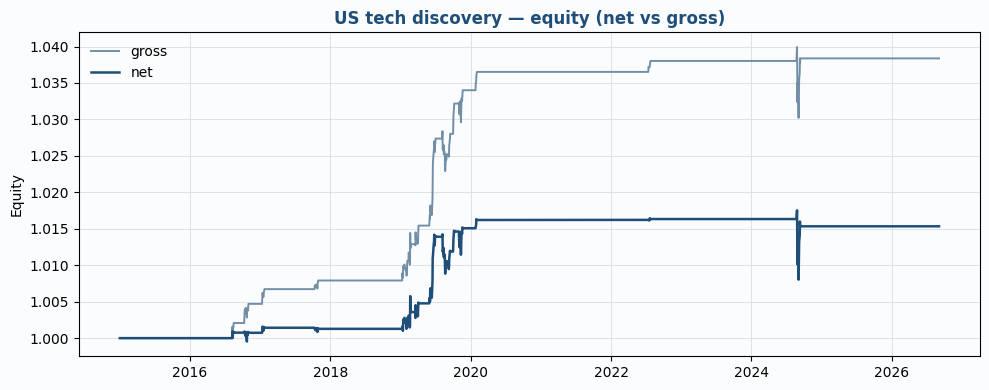

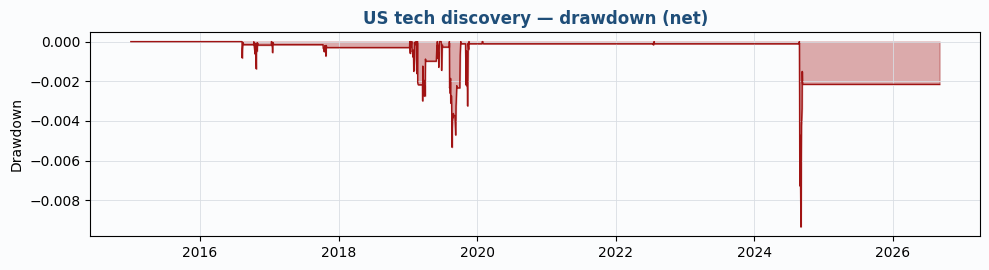

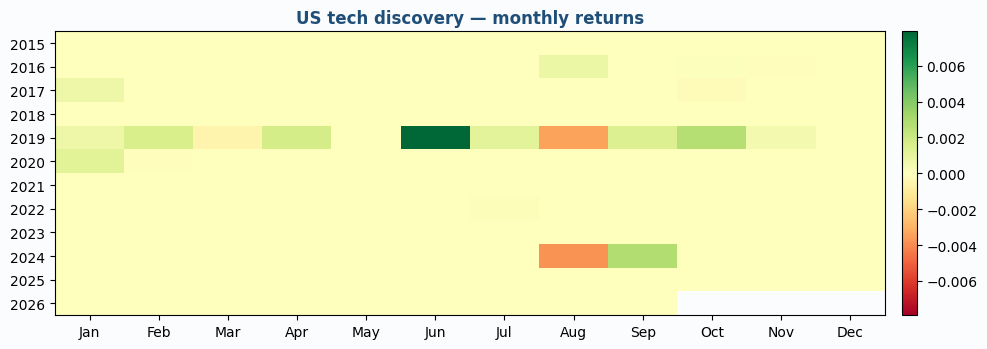

Done.


In [33]:
_ = equity_from_returns(net)
fig = plot_equity_net_gross(net, gross, title="US tech discovery — equity (net vs gross)")
plt.show()
fig = plot_drawdown(net, title="US tech discovery — drawdown (net)")
plt.show()
mret = monthly_returns(net)
fig = plot_monthly_heatmap(mret, title="US tech discovery — monthly returns")
plt.show()
print("Done.")
